# EDA Dataset Frame-Wise

L'exécution de ce notebook a pour prérequis :
- Le téléchargement du dataset `GuitarSet`,
- le démarrage de l'infrastructure docker,
- l'ingestion du dataset `GuitarSet`,
- le prétraitement du dataste `GuitarSet`.

Pour télécharger le dataset `GuitarSet`, utilisez la commande :
```bash
uv run ./audio_midi/main.py --download_datasets --no_idmt_smt_guitar
```

Pour démarrer l'infrastructure docker, utilisez la commande :
```bash
docker-compose up -d
```

Pour lancer la pipeline d'ingestion, utilisez la commande :
```bash
uv run ./audio_midi/main.py --ingest_guitar_set
```

Pour lancer la pipeline de prétraitement, utilisez la commande :
```bash
uv run ./audio_midi/main.py --preprocess_datasets --no_idmt_smt_guitar
```

## Imports

In [1]:
import sys
from pathlib import Path

APP_DIR = Path.cwd().parent
sys.path.append(APP_DIR.as_posix())

In [2]:
# Chemins
OUTPUT_DIRECTORY = APP_DIR / "output"
EDA_DATASET_FRAME_WISE_DIRECTORY = OUTPUT_DIRECTORY / "eda_dataset_frame_wise"
FIGURES_DIRECTORY = EDA_DATASET_FRAME_WISE_DIRECTORY / "figures"
LATEX_DIRECTORY = EDA_DATASET_FRAME_WISE_DIRECTORY / "latex"

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
EDA_DATASET_FRAME_WISE_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LATEX_DIRECTORY.mkdir(parents=True, exist_ok=True)

In [48]:
# Imports EDA
import warnings
from typing import Callable

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
import pretty_midi
import librosa

warnings.filterwarnings("ignore")

RANDOM_STATE = 73

In [4]:
# Imports graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Accessibilité : Daltonisme, Dyslexie, Confort Visuel
sns.set_theme(
    style="whitegrid",
    palette="colorblind",
    context="notebook",
)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.family": "Arial",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.titleweight": "bold",
        "axes.labelsize": 13,
        "axes.labelweight": "medium",
        "axes.edgecolor": "black",
        "axes.linewidth": 1.2,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "lines.linewidth": 2.2,
        "lines.markersize": 7,
        "legend.fontsize": 11,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "grid.linestyle": ":",
        "grid.linewidth": 0.8,
        "grid.alpha": 0.6,
    }
)

COLORBLIND_PALETTE = sns.color_palette("colorblind")

In [5]:
# Imports dataset builder
import logging

from src.pipelines import DatasetBuilderPipeline
from settings.dataset_builder_pipeline_settings import DatasetBuilderPipelineSettings

## Chargement des données

In [6]:
settings_standard = DatasetBuilderPipelineSettings()
dataset_builder_pipeline = DatasetBuilderPipeline(
    logging.getLogger(), settings=settings_standard
)

train_dataset, validation_dataset, test_dataset = dataset_builder_pipeline.run()

In [7]:
X_train, y_train = train_dataset
X_validation, y_validation = validation_dataset
X_test, y_test = test_dataset

## Description générale du dataset

In [8]:
print(
    "Nombre de valeurs nulles dans le jeu d'entraînement :", X_train.isna().sum().sum()
)
print(
    "Nombre de valeurs nulles dans le jeu de validation  :",
    X_validation.isna().sum().sum(),
)
print(
    "Nombre de valeurs nulles dans le jeu de test        :", X_test.isna().sum().sum()
)

Nombre de valeurs nulles dans le jeu d'entraînement : 0
Nombre de valeurs nulles dans le jeu de validation  : 0
Nombre de valeurs nulles dans le jeu de test        : 0


In [9]:
print("Jeu d'entraînement :")
print("  Nombre de frames   :", X_train.shape[0])
print("  Nombre de CQT bins :", X_train.shape[1])
print("  Nombre de pitches  :", y_train.shape[1])
print()

print("Jeu de validation :")
print("  Nombre de frames   :", X_validation.shape[0])
print("  Nombre de CQT bins :", X_validation.shape[1])
print("  Nombre de pitches  :", y_validation.shape[1])
print()

print("Jeu de test :")
print("  Nombre de frames   :", X_test.shape[0])
print("  Nombre de CQT bins :", X_test.shape[1])
print("  Nombre de pitches  :", y_test.shape[1])

Jeu d'entraînement :
  Nombre de frames   : 342529
  Nombre de CQT bins : 84
  Nombre de pitches  : 49

Jeu de validation :
  Nombre de frames   : 38591
  Nombre de CQT bins : 84
  Nombre de pitches  : 49

Jeu de test :
  Nombre de frames   : 91440
  Nombre de CQT bins : 84
  Nombre de pitches  : 49


## Analyse des features CQT

### Analyse de la distribution globale

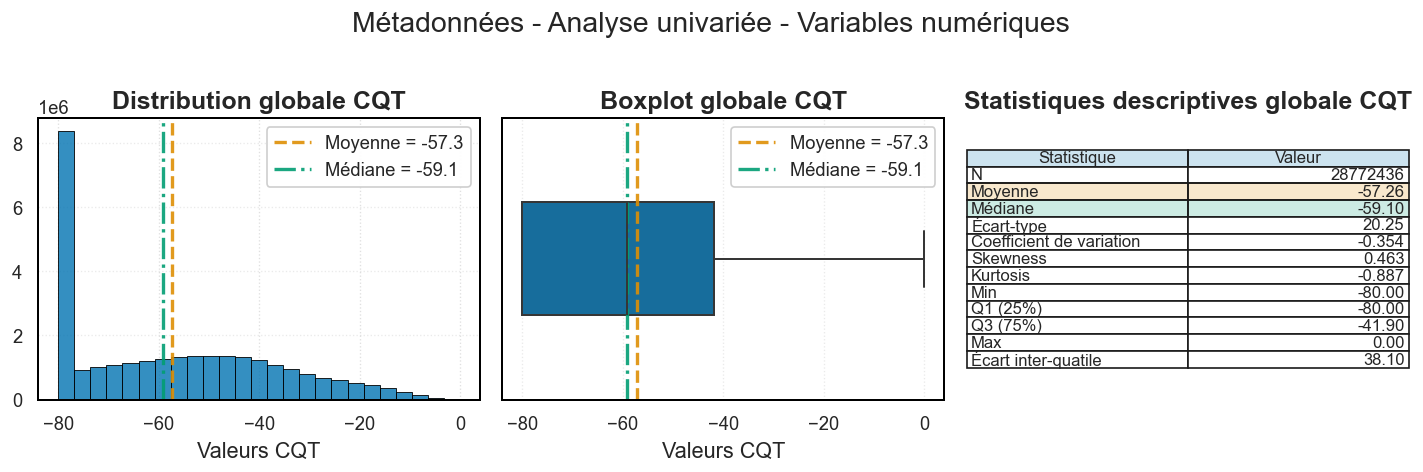

In [ ]:
def create_histplot(ax, values):
    sns.histplot(
        x=values,
        # bins=int(np.sqrt(len(values))),
        bins=int(1 + np.log2(len(values))),
        color=COLORBLIND_PALETTE[0],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.8,
        ax=ax,
    )

    mean_column = np.mean(values)
    median_column = np.median(values)

    ax.axvline(
        mean_column,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_column:.1f}",
    )

    ax.axvline(
        median_column,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_column:.1f}",
    )

    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_boxplot(ax, values):
    sns.boxplot(
        x=values,
        ax=ax,
        color=COLORBLIND_PALETTE[0],
        width=0.4,
        fliersize=4,
        linewidth=1.2,
    )

    mean_val = np.mean(values)
    median_val = np.median(values)

    ax.axvline(
        mean_val,
        color=COLORBLIND_PALETTE[1],
        linestyle="--",
        linewidth=2,
        alpha=0.9,
        label=f"Moyenne = {mean_val:.1f}",
    )

    ax.axvline(
        median_val,
        color=COLORBLIND_PALETTE[2],
        linestyle="-.",
        linewidth=2,
        alpha=0.9,
        label=f"Médiane = {median_val:.1f}",
    )

    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.legend(frameon=True)


def create_stats_panel(ax, values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]

    mean_val = np.mean(values)
    std_val = np.std(values)
    cv = std_val / mean_val if mean_val != 0 else np.nan
    skew = stats.skew(values)
    kurt = stats.kurtosis(values)
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)

    stats_data = [
        ["N", f"{len(values)}"],
        ["Moyenne", f"{mean_val:.2f}"],
        ["Médiane", f"{np.median(values):.2f}"],
        ["Écart-type", f"{std_val:.2f}"],
        ["Coefficient de variation", f"{cv:.3f}"],
        ["Skewness", f"{skew:.3f}"],
        ["Kurtosis", f"{kurt:.3f}"],
        ["Min", f"{np.min(values):.2f}"],
        ["Q1 (25%)", f"{q1:.2f}"],
        ["Q3 (75%)", f"{q3:.2f}"],
        ["Max", f"{np.max(values):.2f}"],
        ["Écart inter-quatile", f"{q3 - q1:.2f}"],
    ]

    table = ax.table(
        cellText=stats_data,
        colLabels=["Statistique", "Valeur"],
        cellLoc="right",
        colLoc="center",
        loc="center",
    )

    # Style
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.1)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor(COLORBLIND_PALETTE[0] + (0.2,))
        else:
            cell.PAD = 0.02
            if col == 0:
                cell.get_text().set_ha("left")
        if row == 2:
            cell.set_facecolor(COLORBLIND_PALETTE[1] + (0.2,))
        if row == 3:
            cell.set_facecolor(COLORBLIND_PALETTE[2] + (0.2,))

    ax.set_axis_off()


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

fig.suptitle("Features - Analyse univariée", fontsize=17)

ax1 = axes[0]
create_histplot(ax1, X_train.values.ravel())
ax1.set_title("Distribution globale CQT")
ax1.set_xlabel("Valeurs CQT")
ax1.set_ylabel(None)

ax2 = axes[1]
create_boxplot(ax2, X_train.values.ravel())
ax2.set_title("Boxplot globale CQT")
ax2.set_xlabel("Valeurs CQT")

ax3 = axes[2]
create_stats_panel(ax3, X_train.values.ravel())
ax3.set_title("Statistiques descriptives globale CQT")

fig.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "global_distribution_cqt.png").as_posix())
plt.show()

### Analyse des corrélations

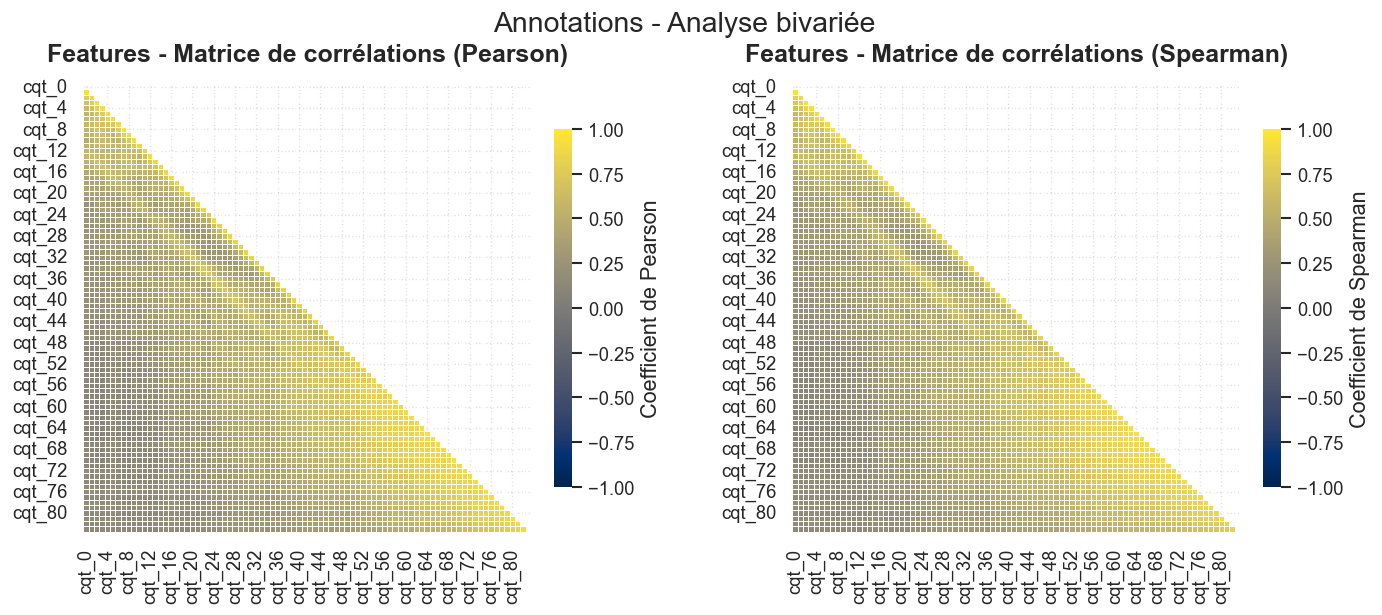

In [ ]:
X_train_sample = X_train.sample(5000)

features_corr_df_pearson = X_train_sample.corr(method="pearson")
features_corr_df_spearman = X_train_sample.corr(method="spearman")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle("Features - Analyse bivariée", fontsize=17)

# ===
# Pearson
# ===

heatmap = sns.heatmap(
    features_corr_df_pearson,
    mask=np.triu(np.ones_like(features_corr_df_pearson, dtype=bool)),
    annot=False,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Pearson"},
    annot_kws={"size": 10},
    ax=ax1,
)
ax1.set_title("Features - Matrice de corrélations (Pearson)", pad=14)

# ===
# Spearman
# ===

heatmap = sns.heatmap(
    features_corr_df_spearman,
    mask=np.triu(np.ones_like(features_corr_df_spearman, dtype=bool)),
    annot=False,
    fmt=".2f",
    cmap="cividis",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "pad": 0.04, "label": "Coefficient de Spearman"},
    annot_kws={"size": 10},
    ax=ax2,
)
ax2.set_title("Features - Matrice de corrélations (Spearman)", pad=14)

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "features_correlations.png").as_posix())
plt.show()

### PCA

In [24]:
pca = PCA()
pca.fit(X_train)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

In [29]:
n_80pct = (cumulative_variance >= 0.80).argmax() + 1
n_90pct = (cumulative_variance >= 0.90).argmax() + 1
n_99pct = (cumulative_variance >= 0.99).argmax() + 1
n_kaiser = sum(pca.explained_variance_ > 1)

print(f"Nombre de composantes pour au moins 80% de variance : {n_80pct}")
print(f"Nombre de composantes pour au moins 90% de variance : {n_90pct}")
print(f"Nombre de composantes pour au moins 99% de variance : {n_99pct}")
print(f"Nombre de valeurs propre supérieures à 1 (Kaiser)   : {n_kaiser}")

n_composantes = min(n_99pct, max(n_90pct, n_kaiser))
print(
    f"\n>>> DÉCISION : {n_composantes} composantes ({cumulative_variance[n_composantes - 1] * 100:.1f}% de variance)"
)

Nombre de composantes pour au moins 80% de variance : 8
Nombre de composantes pour au moins 90% de variance : 15
Nombre de composantes pour au moins 99% de variance : 56
Nombre de valeurs propre supérieures à 1 (Kaiser)   : 84

>>> DÉCISION : 56 composantes (99.0% de variance)


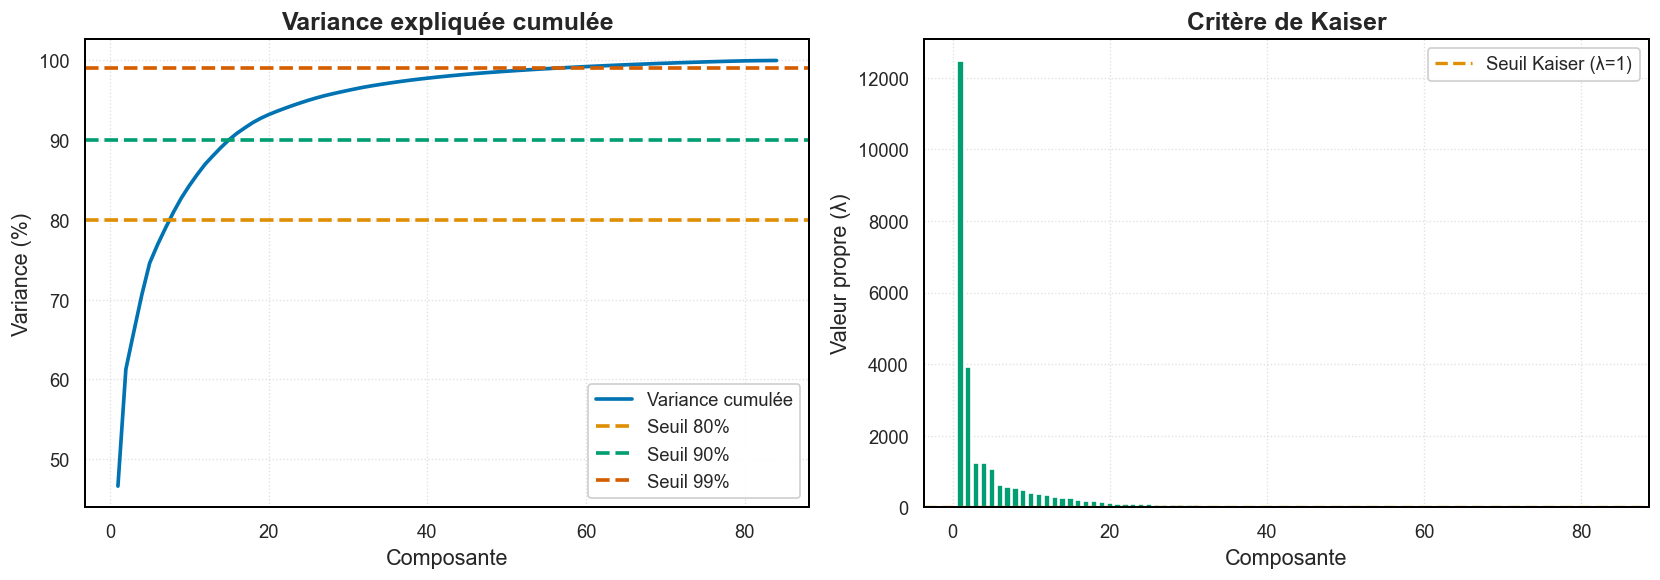

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(1, len(pca.explained_variance_) + 1)
ax1.plot(x, cumulative_variance * 100, label="Variance cumulée")
ax1.axhline(80, color=COLORBLIND_PALETTE[1], linestyle="--", label="Seuil 80%")
ax1.axhline(90, color=COLORBLIND_PALETTE[2], linestyle="--", label="Seuil 90%")
ax1.axhline(99, color=COLORBLIND_PALETTE[3], linestyle="--", label="Seuil 99%")
ax1.set_xlabel("Composante")
ax1.set_ylabel("Variance (%)")
ax1.set_title("Variance expliquée cumulée")
ax1.legend()

colors = [
    COLORBLIND_PALETTE[2] if lam > 1 else COLORBLIND_PALETTE[3]
    for lam in pca.explained_variance_
]
ax2.bar(x, pca.explained_variance_, color=colors)
ax2.axhline(
    1,
    color=COLORBLIND_PALETTE[1],
    linestyle="--",
    linewidth=2,
    label="Seuil Kaiser (λ=1)",
)
ax2.set_xlabel("Composante")
ax2.set_ylabel("Valeur propre (λ)")
ax2.set_title("Critère de Kaiser", fontweight="bold")
ax2.legend()

plt.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "pca.png").as_posix())
plt.show()

## Analyse des activation de pitch

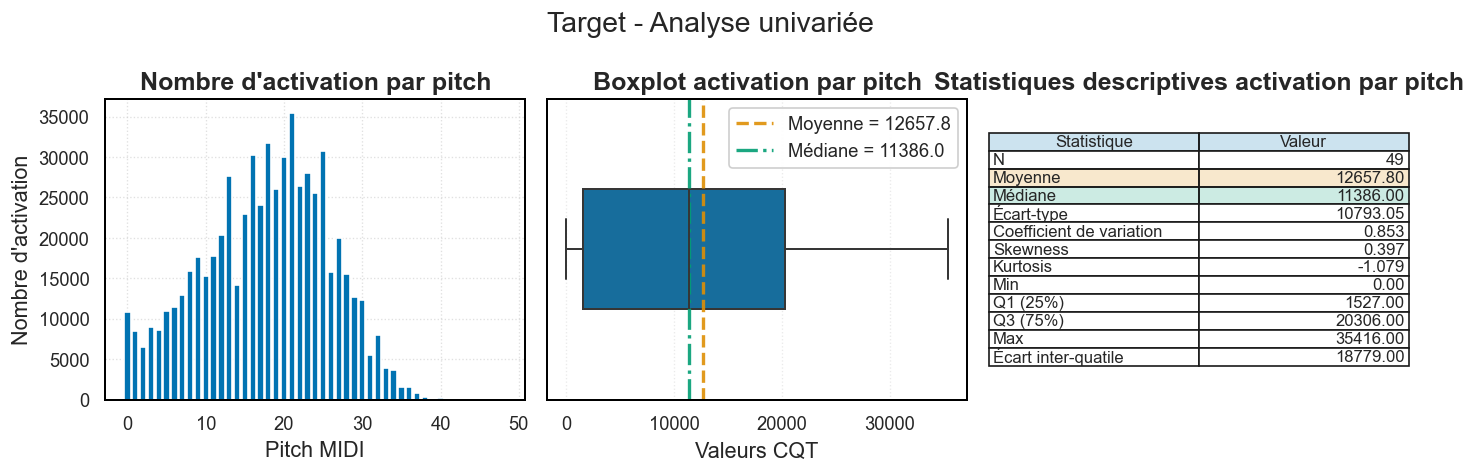

In [40]:
activation_rate = y_train.sum(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

fig.suptitle("Target - Analyse univariée", fontsize=17)

ax1 = axes[0]
ax1.bar(np.arange(len(activation_rate)), activation_rate)
ax1.set_title("Nombre d'activation par pitch")
ax1.set_xlabel("Pitch MIDI")
ax1.set_ylabel("Nombre d'activation")

ax2 = axes[1]
create_boxplot(ax2, activation_rate)
ax2.set_title("Boxplot activation par pitch")
ax2.set_xlabel("Valeurs CQT")

ax3 = axes[2]
create_stats_panel(ax3, activation_rate)
ax3.set_title("Statistiques descriptives activation par pitch")

fig.tight_layout()
plt.savefig((FIGURES_DIRECTORY / "distibution_pitch_activation.png").as_posix())
plt.show()

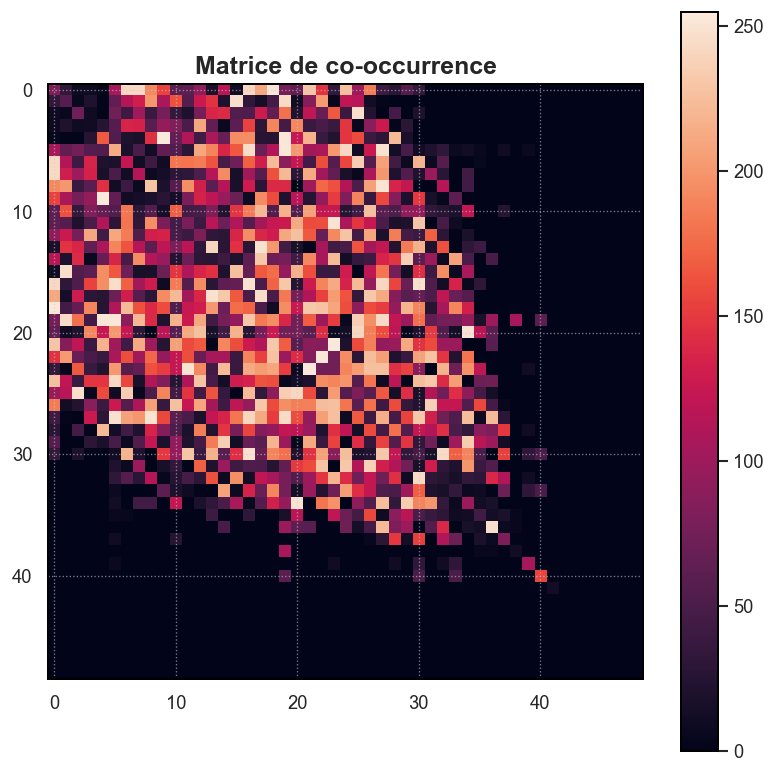

In [ ]:
cooc = y_train.T @ y_train

plt.figure(figsize=(8, 8))
plt.imshow(cooc, aspect="equal")
plt.colorbar()
plt.title("Matrice de co-occurrence")
plt.show()

In [44]:
transition_rate = np.mean(np.any(y_train.values[1:] != y_train.values[:-1], axis=1))
print("Taux de transition :", transition_rate)

Taux de transition : 0.1292595057922272


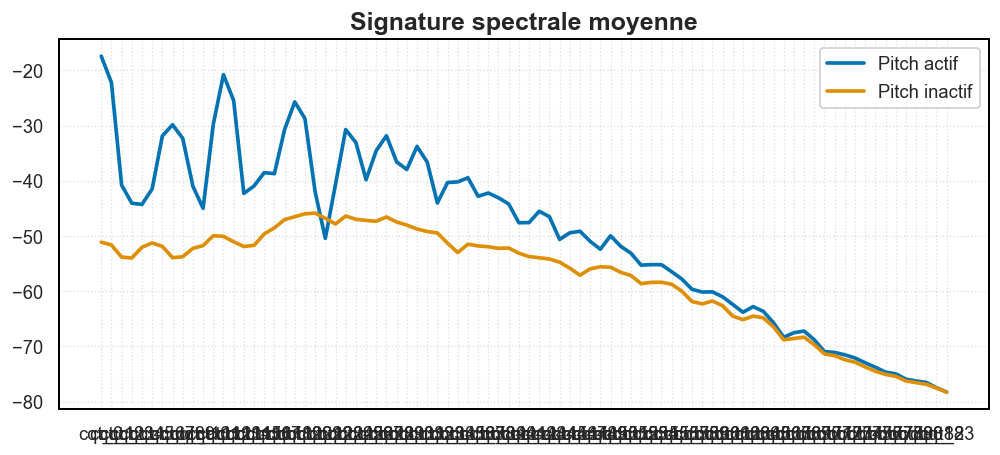

In [ ]:
pitch_id = 60 if y_train.shape[1] > 60 else 0

active = X_train[y_train.values[:, pitch_id] == 1]
inactive = X_train[y_train.values[:, pitch_id] == 0]

plt.figure(figsize=(10, 4))
plt.plot(active.mean(axis=0), label="Pitch actif")
plt.plot(inactive.mean(axis=0), label="Pitch inactif")
plt.legend()
plt.title("Signature spectrale moyenne")
plt.show()

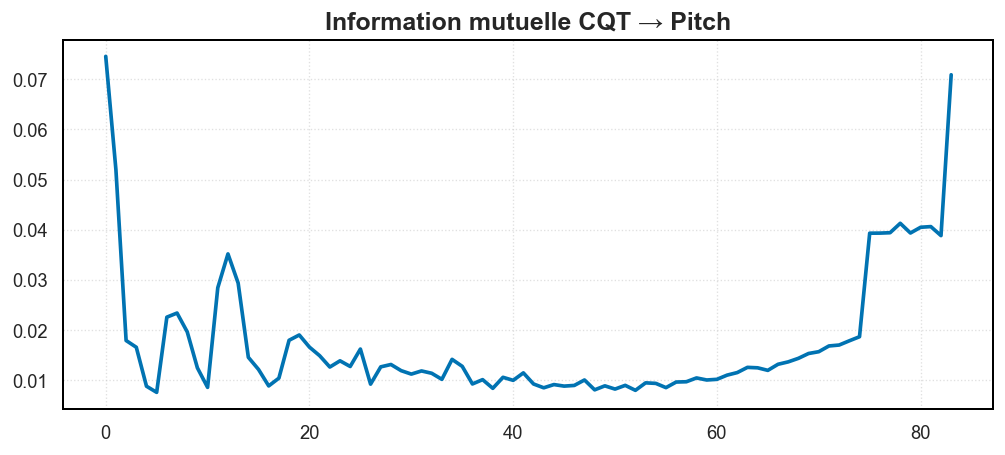

In [ ]:
pitch_id = 0

mi = mutual_info_classif(X_train, y_train.values[:, pitch_id].astype(int))

plt.figure(figsize=(10, 4))
plt.plot(mi)
plt.title("Information mutuelle CQT → Pitch")
plt.show()

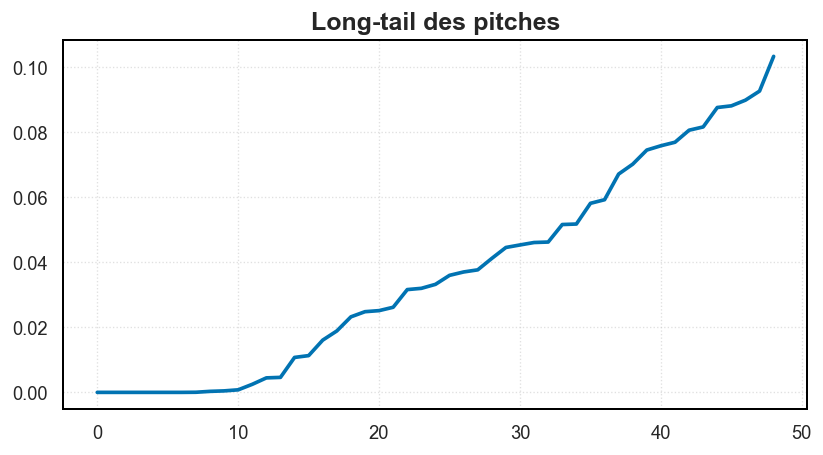

Ratio max/min : 2951.333333333333


In [ ]:
rates = y_train.values.mean(axis=0)

plt.figure(figsize=(8, 4))
plt.plot(np.sort(rates))
plt.title("Long-tail des pitches")
plt.show()

print("Ratio max/min :", rates.max() / np.maximum(rates[rates > 0].min(), 1e-12))
